# Debugging the model

In [1]:
import os

In [8]:
cwd = os.getcwd()
parent = os.path.abspath(os.path.join(cwd, os.pardir))

In [10]:
os.chdir(parent)
print(os.getcwd())

C:\Users\Lenovo\Documents\SCUOLA\UNI\MASTER\2ANNO\HANDS ON GENERATIVE AI\Hands-on-Generative-AI


In [11]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from diffusers import UNet2DModel, VQModel
from src.utils.subVP_processes import DiffusionProcesses

In [12]:
# ==========================================
# 1. Wrapper for Compatibility
# ==========================================
class HuggingFaceWrapper(nn.Module):
    """
    Wraps a Hugging Face UNet to be compatible with subVP_SDE.
    
    1. Scales continuous time t (0 to 1) to discrete steps (0 to 999).
    2. Handles the dictionary output format of Diffusers.
    """
    def __init__(self, hf_model):
        super().__init__()
        self.model = hf_model
        # Standard LDMs use 1000 discrete steps
        self.num_train_timesteps = 1000 

    def forward(self, x, t):
        # t comes in as a tensor of shape (B,) with values in [0, 1]
        # We need to scale this to [0, 999] for the pre-trained UNet
        
        # Clamp to avoid index out of bounds at t=1.0
        t_discrete = (t * (self.num_train_timesteps - 1)).long().clamp(0, self.num_train_timesteps - 1)
        
        # Diffusers models return a class with a .sample attribute
        output = self.model(x, t_discrete).sample
        
        return output

Running on device: cpu
Loading pre-trained LDM (CelebA-HQ 256)...


config.json:   0%|          | 0.00/712 [00:00<?, ?B/s]

C:\Users\Lenovo\anaconda3\envs\myenv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--CompVis--ldm-celebahq-256. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
An error occurred while trying to fetch CompVis/ldm-celebahq-256: CompVis/ldm-celebahq-256 does not appear

unet/diffusion_pytorch_model.bin:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

An error occurred while trying to fetch CompVis/ldm-celebahq-256: CompVis/ldm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


vqvae/diffusion_pytorch_model.bin:   0%|          | 0.00/221M [00:00<?, ?B/s]

Starting Reverse Sampling using subVP_SDE...
Summary stats:
Steps done: 0
Time of last 100 steps: 0.0
Average time of last 100 steps: 0.0
Overall time:0.0
Summary stats:
Steps done: 100
Time of last 100 steps: 108.51206660270691
Average time of last 100 steps: 1.0851206660270691
Overall time:108.51206660270691
Summary stats:
Steps done: 200
Time of last 100 steps: 106.63193011283875
Average time of last 100 steps: 1.0663193011283874
Overall time:215.14399671554565
Summary stats:
Steps done: 300
Time of last 100 steps: 112.57427287101746
Average time of last 100 steps: 1.1257427287101747
Overall time:327.7182695865631
Summary stats:
Steps done: 400
Time of last 100 steps: 107.57669854164124
Average time of last 100 steps: 1.0757669854164122
Overall time:435.29496812820435
Summary stats:
Steps done: 500
Time of last 100 steps: 106.28240084648132
Average time of last 100 steps: 1.0628240084648133
Overall time:541.5773689746857
Summary stats:
Steps done: 600
Time of last 100 steps: 106.372

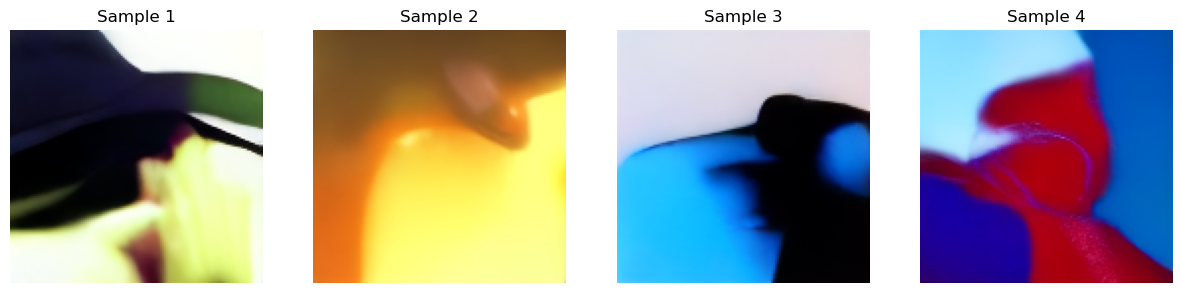

If you see faces above, your 'sample_reverse' logic is CORRECT.
If you see noise, the bug is inside 'sample_reverse' or 'subVP_SDE'.


In [13]:
# ==========================================
# 2. Main Debugging Script
# ==========================================
def run_debug():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running on device: {device}")

    # --- A. Load Proven Pre-trained Models ---
    print("Loading pre-trained LDM (CelebA-HQ 256)...")
    
    # 1. The UNet (Denoising Model)
    # This model expects 32x32 latents and outputs 32x32 noise prediction
    hf_unet = UNet2DModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="unet").to(device)
    
    # 2. The VQ-VAE (Decoder)
    # This model decodes 32x32 latents to 256x256 images
    vqvae = VQModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="vqvae").to(device)
    
    # Wrap the UNet to work with your SDE code
    proven_model = HuggingFaceWrapper(hf_unet)
    proven_model.eval()

    # --- B. Configure Your SDE ---
    # We mock the configuration dictionary expected by your DiffusionProcesses class.
    # Note: beta_min=0.1, beta_max=20 is standard for VP-SDE (matches LDM physics reasonably well).
    debug_config = {
        'ForwardConfig': {
            'beta_min': 0.1,
            'beta_max': 20.0,
            'N': 1000,
            'schedule': 'linear',
            't': None,
            'final': False,
            'eps': 1e-5,
            'closed_formula': True,
            'seed': 42
        },
        'ReverseConfig': {
            'beta_min': 0.1,
            'beta_max': 20.0,
            'N': 1000,           # Number of sampling steps
            'schedule': 'linear',
            't0': 1.0,           # Start time (pure noise)
            't1': 0.0,           # End time (clean image)
            'shape': (4, 3, 32, 32), # B=4, C=3 (Latent Channels), H=32, W=32
            'rev_type': 'sde',   # 'sde' or 'ode'
            'corrector': False,  # Disable corrector for simple debug
            'n_corr': 1,
            'target_snr': 0.16,
            'seed': 42,
            'device': device,
            'dtype': torch.float32
        },
        'LikelihoodConfig': {} 
    }

    # Initialize YOUR process class
    process = DiffusionProcesses(debug_config)

    # --- C. Run YOUR Reverse Sampling ---
    print("Starting Reverse Sampling using subVP_SDE...")
    
    # This calls sde.reverse_euler_step using the Proven Model
    # The input to the loop will be pure noise generated inside sample_reverse
    latents_final = process.sample_reverse(proven_model) 
    
    print(f"Sampling complete. Latent shape: {latents_final.shape}")

    # --- D. Decode and Visualize ---
    print("Decoding latents to images...")
    with torch.no_grad():
        # VQModel expects latents, usually scaled. 
        # LDM latents are often not normalized to unit variance in the same way, 
        # but for visualization this direct pass is usually sufficient.
        # Sometimes LDM output needs scaling by 1/0.18215 (scale factor), 
        # but let's try raw first or check the pipeline config.
        # For CompVis VQGAN, usually no scaling factor is needed unlike KL-Autoencoders.
        
        images = vqvae.decode(latents_final).sample

    # Post-process for display (Clamp -1..1 to 0..1)
    images = (images / 2 + 0.5).clamp(0, 1)
    images = images.cpu().permute(0, 2, 3, 1).numpy()

    # Plot
    fig, axs = plt.subplots(1, 4, figsize=(15, 5))
    for i in range(4):
        axs[i].imshow(images[i])
        axs[i].axis('off')
        axs[i].set_title(f"Sample {i+1}")
    
    plt.show()
    print("If you see faces above, your 'sample_reverse' logic is CORRECT.")
    print("If you see noise, the bug is inside 'sample_reverse' or 'subVP_SDE'.")

if __name__ == "__main__":
    run_debug()